# 03b-04 - The Block and Its Adjustment

The tie points of 03b-03 are observations, and this notebook is where they become a block. The software took every track, guessed where each camera stood from the receiver, and then solved for everything at once, the position and the turn of every photograph, the three coordinates of every point, and the camera itself, so that every ray from a lens through an observed feature passes as closely as it can through the point it observed. The result is the sparse cloud of the lecture's pipeline with the camera stations above it, and the numbers that say how well the rays meet.

We open the reconstruction as the software wrote it, in two coordinate frames, and draw it. We check where it put each camera against where the receiver said, and how it turned each camera against the heading in the file. We write the collinearity equations as ten lines of code, project every point the first photograph observed back into it, and read the residuals the adjustment left. We compare the camera the flight calibrated with the camera the software assumed, and count the block in unknowns and equations. Then we do the adjustment itself, on eight photographs and a few thousand points, in scipy, and watch perturbed cameras find their places again.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math
import time

import numpy as np
import pandas as pd
from PIL import Image
from scipy.optimize import least_squares
from scipy.sparse import lil_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## The reconstruction, as the software wrote it

The software leaves its block behind as a file of shots and points. A shot is one photograph with its pose, three numbers for the rotation as an axis angle vector, whose direction is the axis of the turn and whose length is the angle, and three for the translation; a point is three coordinates and a colour. The kit ships this in `block.npz`, twice. Once in the frame the adjustment worked in, a topocentric frame of east, north and up in metres about a reference point on the field, and once in the map frame, the products' coordinate system minus an offset. The observations, which feature of which shot saw which point, are in `tracks.npz`. Three small functions turn the stored numbers into geometry, the rotation matrix of an axis angle vector, the place of the lens and the direction it looked, and with them the block can be drawn, first as a plan and then the way the lecture's thumbnail showed it, from an oblique angle:

shots      85 photographs, each a rotation of 3 numbers and a translation of 3   reference 85
points     80679, each 3 coordinates and a colour   reference 80679
observed   369157 times, a feature of a shot seeing a point   reference 369157
frames     topocentric for rotation, translation, gps, points; the map frame minus offset for rotation_map, translation_map, gps_map, points_map
           the topocentric frame is centred on latitude 40.34339, longitude -74.65459; the map frame is EPSG:32618 minus an offset
camera     the brown model for a frame of 4000 by 3000 pixels
the camera centres sit -19.3 to -12.1 m above the reference point; the middle nine tenths of the points lie between -89.3 and -74.5 m


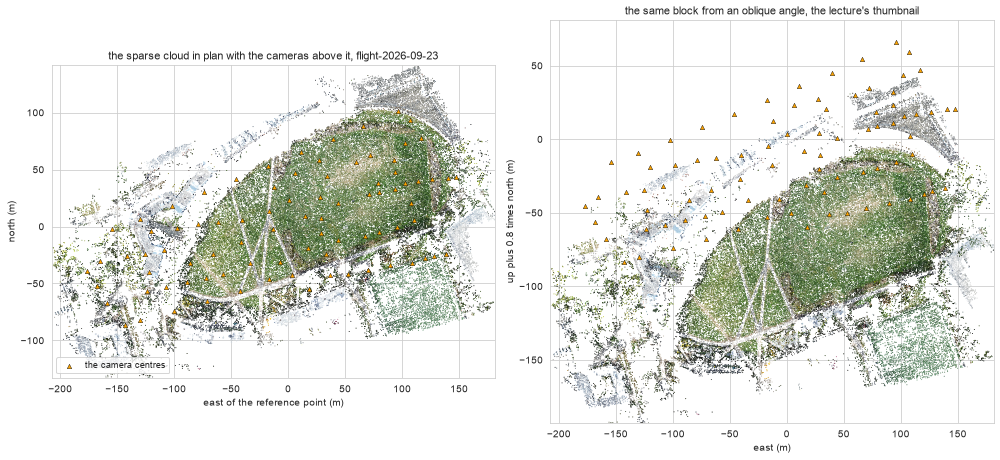

In [2]:
block = np.load("data/block.npz")
tracks = np.load("data/tracks.npz")
names = [str(n) for n in block["names"]]
camera = json.loads(str(block["camera"]))
W, H = int(camera["width"]), int(camera["height"])                    # the full frame the software worked in
reference_lla = json.loads(str(block["reference_lla"]))
print(f"shots      {len(names)} photographs, each a rotation of 3 numbers and a translation of 3   reference {reference['block']['shots']}")
print(f"points     {len(block['points'])}, each 3 coordinates and a colour   reference {reference['block']['points']}")
print(f"observed   {len(tracks['shot'])} times, a feature of a shot seeing a point   reference {reference['block']['observations']}")
print(f"frames     {str(block['frame'])}")
print(f"           the topocentric frame is centred on latitude {reference_lla['latitude']:.5f}, longitude {reference_lla['longitude']:.5f}; the map frame is {str(block['crs'])} minus an offset")
print(f"camera     the {camera['projection_type']} model for a frame of {W} by {H} pixels")


def rodrigues(rv):
    """The rotation matrix of an axis angle vector: turn by its length about its direction."""
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta
    K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])   # the cross product with k, as a matrix
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K


def camera_centre(rotation, translation):
    """Where the lens was: the world point the pose sends to the camera's origin, minus R transposed times t."""
    return -rodrigues(rotation).T @ np.asarray(translation, dtype=float)


def camera_axis(rotation):
    """Which way the camera looked: its own z axis turned into the world."""
    return rodrigues(rotation).T @ np.array([0.0, 0.0, 1.0])


centres = np.array([camera_centre(r, t) for r, t in zip(block["rotation"], block["translation"])])
points = block["points"].astype(float)
colours = block["colors"] / 255.0

oblique = points[:, 2] + 0.8 * points[:, 1]                             # the lecture's oblique view: up plus a share of north
span = lambda a, pad=15: (np.percentile(a, 0.5) - pad, np.percentile(a, 99.5) + pad)   # a few stray points must not set the frame
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
axes[0].scatter(points[:, 0], points[:, 1], s=1, c=colours, linewidths=0)
axes[0].scatter(centres[:, 0], centres[:, 1], s=20, marker="^", color="orange", edgecolor="black", linewidth=0.4, label="the camera centres")
axes[0].set_xlim(*span(points[:, 0])); axes[0].set_ylim(*span(points[:, 1]))
axes[0].set_aspect("equal"); axes[0].legend(loc="lower left", fontsize=9)
axes[0].set_xlabel("east of the reference point (m)"); axes[0].set_ylabel("north (m)")
axes[0].set_title(f"the sparse cloud in plan with the cameras above it, {flight['label']}", fontsize=11)
axes[1].scatter(points[:, 0], oblique, s=1, c=colours, linewidths=0)
axes[1].scatter(centres[:, 0], centres[:, 2] + 0.8 * centres[:, 1], s=20, marker="^", color="orange", edgecolor="black", linewidth=0.4)
axes[1].set_xlim(*span(points[:, 0])); axes[1].set_ylim(min(span(oblique)[0], 0), max(span(oblique)[1], (centres[:, 2] + 0.8 * centres[:, 1]).max() + 15))
axes[1].set_xlabel("east (m)"); axes[1].set_ylabel("up plus 0.8 times north (m)")
axes[1].set_title("the same block from an oblique angle, the lecture's thumbnail", fontsize=11)
fig.tight_layout()
print(f"the camera centres sit {centres[:, 2].min():.1f} to {centres[:, 2].max():.1f} m above the reference point; the middle nine tenths of the points lie between {np.percentile(points[:, 2], 5):.1f} and {np.percentile(points[:, 2], 95):.1f} m")

Three counts and two frames. The shots are the photographs the software kept, each with six numbers of pose, and the points are the tracks it could place in space. The third count is how many times a point was observed, which is the number of tie point measurements the adjustment had to fit, and it is several times the number of points because every point lives in several photographs. The frame line says which arrays are in which frame, and the line after it gives the latitude and longitude the topocentric frame is centred on. In the plan the cloud is the field and everything around it that the photographs reached, coloured from the photographs themselves, and the orange triangles are where the software concluded each photograph was taken; they trace the pattern the drone flew. The oblique view is the lecture's thumbnail made from your own flight. The ground is the coloured sheet, the cameras hang in one plane above it, and the crowns and roofs stand up out of the sheet; the last line prints the cameras' height above the reference point and the band in which most of the points lie, and the gap between the two is the flying height above the ground. Every camera and every point here came out of one solve, and the rest of this notebook checks that solve piece by piece.

## Where the software says each camera was

The receiver on the drone wrote a position into every file, and 03b-01 showed the accuracy the software was told to give it. The adjustment treated those positions as a weak anchor. The block had to end up near them, but each camera was free to move by about that accuracy if the photographs demanded it, so the difference between where the software put a camera and where the receiver said it was is a measure of the receiver, not of the block. Here it is, axis by axis, and as arrows on the plan:

RMS east       0.511 m   reference 0.511
RMS north      0.521 m   reference 0.521
RMS up         0.709 m   reference 0.709
distance       mean 0.903 m in three dimensions, median 0.817 m   reference 0.903 and 0.817; the report's own average is 0.903
the software was told to trust the receiver to 3 m


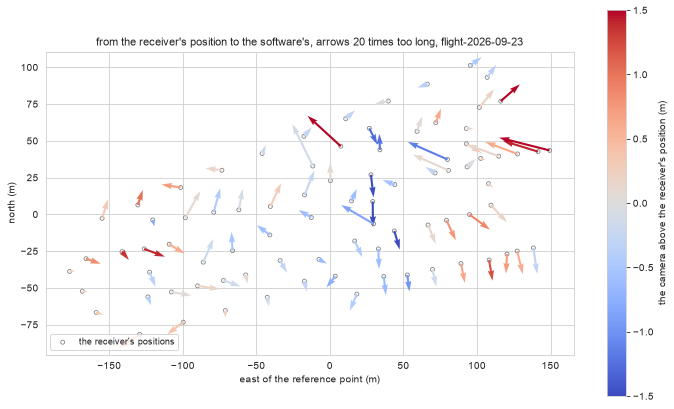

In [3]:
gps = np.asarray(block["gps"], dtype=float)                             # the receiver's positions, in the adjustment's frame
difference = centres - gps
rms = np.sqrt((difference ** 2).mean(axis=0))
distance = np.linalg.norm(difference, axis=1)
receiver = reference["block"]["receiver"]
print(f"RMS east       {rms[0]:.3f} m   reference {receiver['rms_e_m']}")
print(f"RMS north      {rms[1]:.3f} m   reference {receiver['rms_n_m']}")
print(f"RMS up         {rms[2]:.3f} m   reference {receiver['rms_up_m']}")
print(f"distance       mean {distance.mean():.3f} m in three dimensions, median {np.median(distance):.3f} m   reference {receiver['mean_3d_m']} and {receiver['median_3d_m']}; the report's own average is {receiver['report_average_error_m']:.3f}")
print(f"the software was told to trust the receiver to {receiver['assumed_accuracy_m']} m")

stretch = 20                                                            # the arrows are lengthened so that a metre shows at the block's scale
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(gps[:, 0], gps[:, 1], s=16, facecolor="none", edgecolor="grey", linewidth=0.8, label="the receiver's positions")
arrows = ax.quiver(gps[:, 0], gps[:, 1], difference[:, 0] * stretch, difference[:, 1] * stretch, difference[:, 2],
                   angles="xy", scale_units="xy", scale=1, cmap="coolwarm", norm=plt.Normalize(-1.5, 1.5), width=0.004)
fig.colorbar(arrows, ax=ax, label="the camera above the receiver's position (m)", shrink=0.8)
ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=9)
ax.set_xlabel("east of the reference point (m)"); ax.set_ylabel("north (m)")
ax.set_title(f"from the receiver's position to the software's, arrows {stretch} times too long, {flight['label']}", fontsize=11)
fig.tight_layout()

Read the three RMS lines as the receiver's error in each axis, then the distance line as one number for it; the report's average is the same quantity computed by the software from the same cameras and the same positions, so the two should agree closely. Hold all of them against the last line, the accuracy the software was told to assume. If the differences are well inside it, the anchor held loosely and the photographs decided where the cameras were, which is what we want; if any camera sat near or beyond it, the software would have had to choose between the receiver and the pictures. In the figure the arrows are the horizontal part of the difference, lengthened so that a metre shows at the scale of the block, and their colour is the vertical part. Look for a pattern. Arrows that all point one way are a shift of the whole block, which the anchor cannot see and which only ground control can fix; arrows that point every way are the receiver's noise. Remember that none of this says whether the block sits in the right place on the Earth, only how far each camera moved from where the receiver had it.

## How each camera was turned

The other half of a pose is the rotation. The drone wrote its heading into every file, the yaw of the aircraft, and 03b-01 showed that the software never used the orientation columns and assumed every camera looked straight down. Now the adjustment has solved for the true rotation of every camera, and we can ask two questions of it: which way the top of each picture pointed, held against the heading in the file, and how far from straight down each camera looked. The top of the picture is the image's negative y axis turned into the world, and the tilt is the angle between the camera's axis and the downward vertical:

the picture's top against the file's yaw   median -0.57 degrees   reference -0.57
tilt from straight down                    median 1.08 degrees, largest 1.80   reference 1.08 and 1.8
the gimbal pitch the files wrote           median 0.0 degrees   reference 0.0


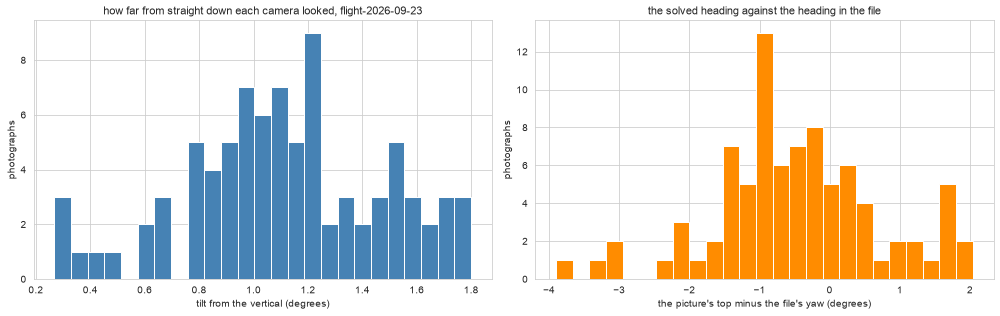

In [4]:
photos = pd.read_csv("data/photos.csv")
image_up = np.array([rodrigues(r).T @ np.array([0.0, -1.0, 0.0]) for r in block["rotation"]])       # the picture's top, in the world
up_azimuth = (np.degrees(np.arctan2(image_up[:, 0], image_up[:, 1])) + 360) % 360                  # clockwise from north, like a heading
yaw_by_file = dict(zip(photos["file"], photos["flight_yaw_deg"]))
yaw_difference = np.array([((up_azimuth[i] - (yaw_by_file.get(n, np.nan) % 360)) + 180) % 360 - 180 for i, n in enumerate(names)])
tilt = np.array([math.degrees(math.acos(max(-1.0, min(1.0, -camera_axis(r)[2])))) for r in block["rotation"]])
orientation = reference["block"]["orientation"]
print(f"the picture's top against the file's yaw   median {np.nanmedian(yaw_difference):+.2f} degrees   reference {orientation['yaw_difference_median_deg']}")
print(f"tilt from straight down                    median {np.median(tilt):.2f} degrees, largest {tilt.max():.2f}   reference {orientation['tilt_median_deg']} and {orientation['tilt_max_deg']}")
print(f"the gimbal pitch the files wrote           median {photos['gimbal_pitch_deg'].median():.1f} degrees   reference {orientation['gimbal_pitch_written_deg']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(tilt, bins=25, color="steelblue")
axes[0].set_xlabel("tilt from the vertical (degrees)"); axes[0].set_ylabel("photographs")
axes[0].set_title(f"how far from straight down each camera looked, {flight['label']}", fontsize=11)
axes[1].hist(yaw_difference[np.isfinite(yaw_difference)], bins=25, color="darkorange")
axes[1].set_xlabel("the picture's top minus the file's yaw (degrees)"); axes[1].set_ylabel("photographs")
axes[1].set_title("the solved heading against the heading in the file", fontsize=11)
fig.tight_layout()

The first line is the heading check. The top of every picture, as the adjustment turned it, should agree with the yaw the aircraft wrote up to the offset between the aircraft's nose and the camera's mount and the small errors of the compass, so read the median as that offset and the spread of the right-hand histogram as the compass. The second line is the tilt the files never recorded. The gimbal held the camera level to within the fraction of a degree the median shows, and the largest value is the photograph where it did least well, usually one taken while the aircraft turned. The third line is what the files said about it, a pitch of zero for every photograph, which is the gimbal's target and not its achievement. In the photogrammetric convention these are the three angles omega, phi and kappa of the lecture's collinearity slide, omega and phi being the two components of the tilt and kappa the heading, and the axis angle vector in the file is the same rotation written as one turn about one axis rather than three turns about three.

## The collinearity equations, in ten lines

The lecture gave the condition in words. The lens, a point on the ground and its image lie on one straight line. As code it is a function that takes a point in the world and a pose and returns the pixel where that point must appear. The steps are to turn and move the point into the camera's frame, divide by depth to reach the image plane, apply the lens distortion the software calibrated, and scale by the focal length into pixels. The software's convention, which the feature files share, measures the image plane in units of the longer side of the frame and centres it, so the last lines add half the width and half the height. With the function written, we project every point that the first photograph observed back into it and compare with where its feature actually was. The differences are the residuals, the adjustment's leftovers:

DJI_0823.JPG observed 3383 points   reference 3383
residual   median 0.683 px   reference 0.683; the report's average over the whole block is 1.012
           mean 1.045 px over the observations under 20 px   reference 1.045
           0.03% of the observations land 20 px or more from their feature   reference 0.03%


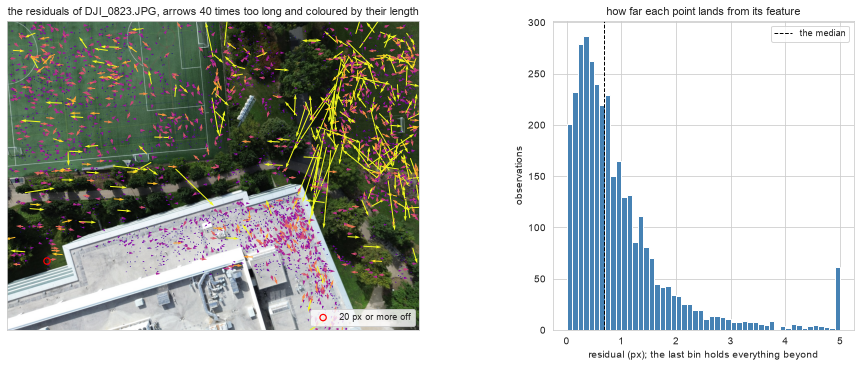

In [5]:
def project(X, rotation, translation, cam, width, height):
    """The collinearity equations: world points into pixels of a photograph of the given size, with the Brown
    distortion the software calibrated. Returns u, v and the depth along the camera's axis."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)      # the points in the camera's frame
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x, y = p[:, 0] / depth, p[:, 1] / depth                                   # the perspective division
    r2 = x * x + y * y
    radial = 1.0 + cam["k1"] * r2 + cam["k2"] * r2 ** 2 + cam["k3"] * r2 ** 3   # the lens bends a ray by this factor
    xd = x * radial + 2.0 * cam["p1"] * x * y + cam["p2"] * (r2 + 2.0 * x * x)  # plus a little decentring
    yd = y * radial + 2.0 * cam["p2"] * x * y + cam["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)
    u = (cam["focal_x"] * xd + cam["c_x"]) * size + width / 2.0 - 0.5           # normalised units into pixels
    v = (cam["focal_y"] * yd + cam["c_y"]) * size + height / 2.0 - 0.5
    return u, v, depth


shot_a = names.index(choices["photos"]["a"]["name"])
seen = tracks["shot"] == shot_a                                          # every observation the first photograph made
observed_u = tracks["x"][seen] * max(W, H) + W / 2 - 0.5                  # its features, as pixels of the full frame
observed_v = tracks["y"][seen] * max(W, H) + H / 2 - 0.5
u, v, depth = project(block["points"][tracks["point"][seen]], block["rotation"][shot_a], block["translation"][shot_a], camera, W, H)
du, dv = u - observed_u, v - observed_v
residual = np.hypot(du, dv)
residual_ref = reference["block"]["residual_a"]
print(f"{choices['photos']['a']['name']} observed {seen.sum()} points   reference {residual_ref['observations']}")
print(f"residual   median {np.median(residual):.3f} px   reference {residual_ref['median_px']}; the report's average over the whole block is {reference['block']['report_reprojection_error_px']:.3f}")
print(f"           mean {residual[residual < 20].mean():.3f} px over the observations under 20 px   reference {residual_ref['mean_under_20_px']}")
print(f"           {(residual >= 20).mean():.2%} of the observations land 20 px or more from their feature   reference {residual_ref['share_beyond_20_px']:.2%}")

photo = np.asarray(Image.open("data/photo_a.jpg"))
sample_h, sample_w = photo.shape[:2]                                     # the kit's photograph is smaller than the frame
to_sample = sample_w / W
stretch = 40
close = residual < 20
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [2.3, 1]})
axes[0].imshow(photo)
arrows = axes[0].quiver(observed_u[close] * to_sample, observed_v[close] * to_sample, du[close] * to_sample * stretch, dv[close] * to_sample * stretch, residual[close],
                        angles="xy", scale_units="xy", scale=1, cmap="plasma", norm=plt.Normalize(0, 3), width=0.0025)
axes[0].scatter(observed_u[~close] * to_sample, observed_v[~close] * to_sample, s=40, facecolor="none", edgecolor="red", linewidth=1.2, label="20 px or more off")
axes[0].legend(loc="lower right", fontsize=9); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title(f"the residuals of {choices['photos']['a']['name']}, arrows {stretch} times too long and coloured by their length", fontsize=11)
axes[1].hist(np.clip(residual, 0, 5), bins=50, color="steelblue")
axes[1].axvline(np.median(residual), color="black", linestyle="--", linewidth=1, label="the median")
axes[1].legend(fontsize=9); axes[1].set_xlabel("residual (px); the last bin holds everything beyond"); axes[1].set_ylabel("observations")
axes[1].set_title("how far each point lands from its feature", fontsize=11)
fig.tight_layout()

The first line says how many of the block's points this photograph observed. The residual lines are the adjustment's honesty. The median is how far a typical point lands from the feature that observed it, in pixels of the full frame, and the report's average is the same idea over every photograph of the block, so the two should be close but need not agree, since one photograph is not the block. A well behaved block has a median under a pixel, and a feature is itself located to a fraction of a pixel, so there is not much room below this. The third line is the mean without the outliers and the fourth says how many outliers there are, observations that landed twenty pixels or more away. Those are the matches the geometric check of 03b-03 let through, a repeated pattern on a roof or a corner of a moving shadow, which the adjustment could not fit and did not let pull the rest. In the picture the arrows are the residual vectors, lengthened so that a pixel shows and coloured by their length, and the red rings are the outliers. Look for structure. If the arrows all pointed outward from the centre the distortion model would be wrong; if they all pointed one way the pose would be. Random directions of random small lengths are what a fitted block leaves behind. Then look at where the long arrows gather and where the short ones do. Leaves move between photographs and a feature on a moving leaf is not the same point twice, while a roof edge and a path are, so the crowns carry the long arrows and the built ground the short ones, and the residual map is also a map of what held still. The histogram shows the same thing as a distribution, the dashed line being the median.

## Two frames, one block

The block above lives in the frame the adjustment worked in. The products of the flight, the depth maps, the dense cloud, the mesh, the surface model and the orthomosaic, live in another, the map frame, which is the coordinate system of the orthomosaic of 03-06 with an offset subtracted so that the numbers stay small. The software carried the block from one to the other after adjusting it, and `block.npz` holds both. The two frames are not the same up to a shift. A map projection has a scale factor, so a metre on the ground is not quite a metre on the map, and its grid north is not quite true north. We fit the same residuals with the map frame poses and points, check the affine the kit fitted between the frames, and read its scale and its turn:

In [6]:
u_map, v_map, _ = project(block["points_map"][tracks["point"][seen]], block["rotation_map"][shot_a], block["translation_map"][shot_a], camera, W, H)
residual_map = np.hypot(u_map - observed_u, v_map - observed_v)
print(f"the same observations against the map frame block   median residual {np.median(residual_map):.3f} px, against {np.median(residual):.3f} in the adjustment's frame   reference {residual_ref['map_frame_median_px']}")

A, b = block["to_map_A"], block["to_map_b"]                              # points_map is A times points plus b, fitted on all the points
carried = block["points"].astype(float) @ A.T + b
print(f"the affine carries every point onto the map frame to within {np.abs(carried - block['points_map']).max() * 1000:.2f} mm")


def affine_parts(A):
    # the horizontal scale and turn of an affine that is nearly a similarity in the plane
    scale = math.sqrt(abs(np.linalg.det(A[:2, :2])))
    angle = math.degrees(math.atan2(A[1, 0] - A[0, 1], A[0, 0] + A[1, 1]))
    return scale, angle


scale, angle = affine_parts(A)
print(f"its horizontal scale is {scale:.6f} and its turn {angle:+.4f} degrees   reference {choices['to_map']['scale']} and {choices['to_map']['angle_deg']}")
print(f"the map frame is {str(block['crs'])} minus the offset {block['offset'][0]:.0f}, {block['offset'][1]:.0f}; the depth map, the dense cloud, the mesh, the surface model and the mosaic of the next notebooks all live in it")

the same observations against the map frame block   median residual 2.659 px, against 0.683 in the adjustment's frame   reference 2.659
the affine carries every point onto the map frame to within 0.02 mm
its horizontal scale is 0.999611 and its turn +0.2236 degrees   reference 0.999611 and 0.2236
the map frame is EPSG:32618 minus the offset 529336, 4465929; the depth map, the dense cloud, the mesh, the surface model and the mosaic of the next notebooks all live in it


Two medians for one set of observations, and the map frame's is the larger. The reason is in the two lines after it. The affine that carries the block from one frame to the other is nearly a similarity in the plane, and its scale and its turn are not the software's doing but the map's. The scale is the projection's scale factor at the site, the amount by which a UTM zone shrinks or stretches distances according to how far the site lies from the zone's central meridian, and the turn is the grid convergence, the angle between grid north and true north at this longitude. Both are properties of the coordinate system, and both would come out the same for any flight over this field. The block itself is rigid, so applying a map that scales the horizontal and not the vertical leaves rotations that are no longer exactly rotations, and the software re-orthonormalised them, which costs the pixel or so of residual the first line shows. That is the price of living in a map. The last line says where everything from here on lives. Every product of the following notebooks is in the map frame, and whenever we project a point from a product into a photograph we use the map frame pose, as the residual here tells us we must.

## The camera the flight calibrated

The software began with a camera it assumed from the files, a focal length from the 35 mm equivalent, the principal point at the centre and no distortion, and 03b-01 showed that the focal length the EXIF focal and the pixel pitch imply is a different number. The adjustment then treated the camera's own numbers as unknowns and solved for them along with the poses, which is the self-calibration of the lecture. Here is the camera the flight calibrated beside the camera the software assumed, its distortion curve out to the corner of the frame, and one experiment, the residuals of the first photograph projected through the assumed camera instead:

focal length      calibrated 2548.7 px, assumed 2666.7 px, from the EXIF focal and the pixel pitch 2800.0 px   reference 2548.7, 2666.7, 2800.0
                  the flight changed the assumed focal length by -4.42 percent   reference -4.42
principal point   +8.02, -3.79 px from the centre of the frame   reference [8.02, -3.79]
radial k1 k2 k3   +0.06731, -0.09612, +0.05211   reference 0.06731, -0.09612, 0.05211
decentring p1 p2  -0.000126, -0.000202   reference -0.000126, -0.000202
at the corner the lens moves a point +23.5 px along the radius   reference 23.5
the same points through the assumed camera   median residual 42.60 px, against 0.683 with the calibrated one   reference 42.6


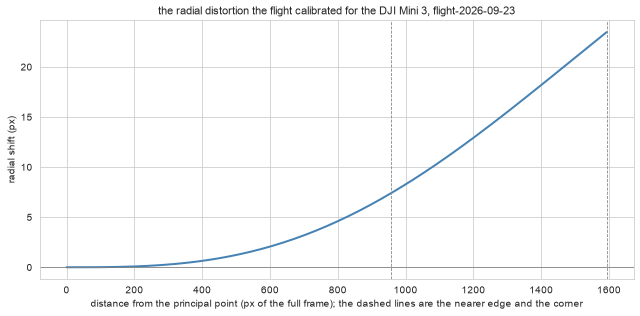

In [7]:
prior = json.loads(str(block["camera_prior"]))
size = max(W, H)
calibration = reference["block"]["calibration"]
pixel_pitch_m, focal_m = 2.4e-6, flight["focal_mm"] * 1e-3            # the aircraft's sensor and lens, the constants of 03b-01
print(f"focal length      calibrated {camera['focal_x'] * size:.1f} px, assumed {prior['focal_x'] * size:.1f} px, from the EXIF focal and the pixel pitch {focal_m / pixel_pitch_m:.1f} px   reference {calibration['focal_px']}, {calibration['focal_prior_px']}, {calibration['focal_from_exif_px']}")
print(f"                  the flight changed the assumed focal length by {(camera['focal_x'] / prior['focal_x'] - 1) * 100:+.2f} percent   reference {calibration['focal_change_percent']}")
print(f"principal point   {camera['c_x'] * size:+.2f}, {camera['c_y'] * size:+.2f} px from the centre of the frame   reference {calibration['principal_point_px']}")
print(f"radial k1 k2 k3   {camera['k1']:+.5f}, {camera['k2']:+.5f}, {camera['k3']:+.5f}   reference {calibration['k1']}, {calibration['k2']}, {calibration['k3']}")
print(f"decentring p1 p2  {camera['p1']:+.6f}, {camera['p2']:+.6f}   reference {calibration['p1']}, {calibration['p2']}")

corner = math.hypot(0.5, H / size / 2)                                   # the corner of the frame, in normalised units
r = np.linspace(0, corner, 200)
shift_px = r * (camera["k1"] * r ** 2 + camera["k2"] * r ** 4 + camera["k3"] * r ** 6) * camera["focal_x"] * size
print(f"at the corner the lens moves a point {shift_px[-1]:+.1f} px along the radius   reference {calibration['radial_distortion_at_corner_px']}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(r * camera["focal_x"] * size, shift_px, color="steelblue", linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(H / size / 2 * camera["focal_x"] * size, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(corner * camera["focal_x"] * size, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("distance from the principal point (px of the full frame); the dashed lines are the nearer edge and the corner")
ax.set_ylabel("radial shift (px)")
ax.set_title(f"the radial distortion the flight calibrated for the {flight['aircraft']}, {flight['label']}", fontsize=11)
fig.tight_layout()

u_prior, v_prior, _ = project(block["points"][tracks["point"][seen]], block["rotation"][shot_a], block["translation"][shot_a], prior, W, H)
print(f"the same points through the assumed camera   median residual {np.median(np.hypot(u_prior - observed_u, v_prior - observed_v)):.2f} px, against {np.median(residual):.3f} with the calibrated one   reference {residual_ref['with_prior_camera_median_px']}")

Three focal lengths in the first line, and the flight chose. The assumed one came from the 35 mm equivalent in the file and the third from the lens's stated focal length over the pixel pitch, and they disagree before the flight has said anything; the calibrated one is what the block needed for its rays to meet, and the second line says by how much it moved from the assumption. Read which of the two it landed nearer, and remember that a nadir block cannot pin a focal length very firmly, which the last section of this notebook has you test. The principal point line says how far from the centre of the frame the lens's axis meets the sensor, in pixels; a few pixels is normal for a consumer lens. The distortion coefficients are hard to read as numbers, so the curve draws them, how far a point is pushed along the radius, in pixels, as a function of its distance from the centre; the dashed lines are the nearer edge of the frame and its corner, and the printed value is the shift at the corner. A positive shift means the lens put the point farther from the centre than a pinhole would have, a negative one nearer, and the polynomial in the squared radius lets the curve bend back; the sign and the size at the corner are what to remember. The last line is the experiment, and it is the point of the section. The same points through the assumed camera land several pixels from their features with the poses and the points unchanged, so without self-calibration this block could not have fitted at all, and the software solved for the camera because it had to.

## A block, counted

The lecture counted Wolf's block of two strips of four photographs, 126 unknowns against 152 equations, a redundancy of 26. Here is the same count on your own block, with the eight numbers of the camera added to the unknowns because the flight solved for them too:

In [8]:
n_shots, n_points, n_observations = len(names), len(block["points"]), len(tracks["shot"])
unknowns = n_shots * 6 + n_points * 3 + 8
equations = 2 * n_observations
print(f"unknowns     {n_shots} shots times 6, plus {n_points} points times 3, plus 8 for the camera = {unknowns}   reference {reference['block']['unknowns']}")
print(f"equations    {n_observations} observations times 2 = {equations}   reference {reference['block']['equations']}")
print(f"redundancy   {equations - unknowns}, which is {equations / unknowns:.1f} equations for every unknown   reference {reference['block']['redundancy']}")

unknowns     85 shots times 6, plus 80679 points times 3, plus 8 for the camera = 242555   reference 242555
equations    369157 observations times 2 = 738314   reference 738314
redundancy   495759, which is 3.0 equations for every unknown   reference 495759


The points carry nearly all the unknowns and the cameras almost none, which is why a block of thousands of photographs is still a solvable problem. Every point is seen by few cameras and every camera sees few points, so the system is enormous but sparse, and that sparsity is what the solver of the next section is told about. The redundancy is the surplus of equations over unknowns, and the ratio after it is the easier number to carry, several equations for every unknown where the lecture's small block had barely more than one. That surplus is what the word adjustment means. No solution satisfies every equation, so least squares picks the one with the smallest residuals, and those residuals are the numbers of the collinearity section. Redundancy is also what lets outliers be found. With barely enough equations a wrong observation is simply fitted; with many it stands out.

## The adjustment itself, on eight photographs

Everything so far has read the software's solution. Now we make one. The whole block is too large for a notebook to solve in a few seconds, so we take the eight photographs of the neighbourhood that 03b-03 built its tracks from, the points that at least four of them see, up to a few thousand of them chosen at random, and their observations. The unknowns are six per photograph and three per point, with the calibrated camera held fixed. The observations that disagree with the software's solution by more than four pixels are dropped first, the outlier cut, and every point keeps at least two views. The receiver's positions enter as weak priors, a residual of each camera centre against the receiver divided by three metres, so that the block cannot drift or turn as a whole. Then we spoil the software's poses on purpose, a random turn of a few tenths of a degree and a random move of half a metre for every camera, and ask `scipy.optimize.least_squares` to find its way back, telling it which residuals depend on which unknowns through a sparsity pattern and giving it a robust loss that stops fitting an observation once it is a pixel or more off:

the sub-block    8 shots, 2129 points, 10134 observations after dropping 395   reference 8, 2129, 10134 after dropping 395
                 6435 unknowns, 20268 equations, redundancy 13833   reference 6435, 20268, 13833
RMS residual     0.987 px at the software's solution   reference 0.987
                 14.440 px after the perturbation   reference 14.44
                 0.849 px after the solve   reference 0.849
camera centres   pushed 0.358 m by the perturbation, back to within 0.152 m of the software's after the solve (medians)   reference 0.358 and 0.152
the solve took   2.2 s and 82 evaluations of the residuals on this machine; the reference carries no timing, since that is the machine's


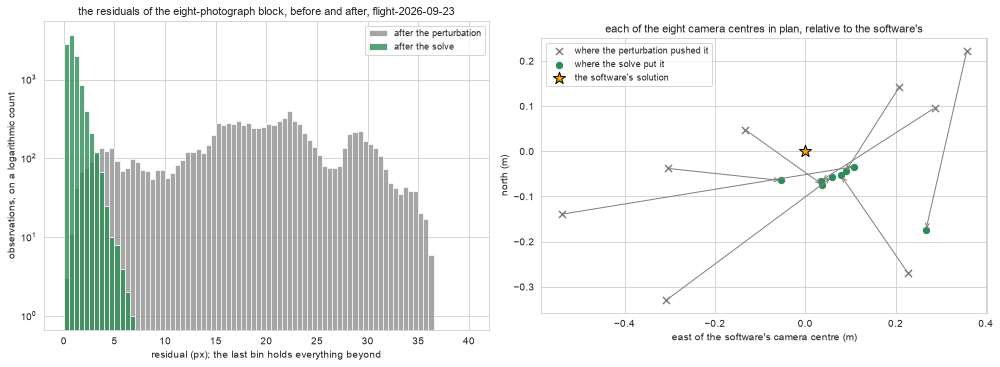

In [9]:
def gather(block, tracks, shot_indices, cam, n_points, min_views, max_residual_px, rng):
    """The observations of a sub-block: the given shots and up to n_points of the points that at least min_views
    of them see, cut to the observations within max_residual_px of the software's own solution."""
    W, H = int(cam["width"]), int(cam["height"]); size = max(W, H)
    picked = np.isin(tracks["shot"], shot_indices)
    point, shot = tracks["point"][picked].astype(np.int64), tracks["shot"][picked].astype(np.int64)
    fu, fv = tracks["x"][picked] * size + W / 2.0 - 0.5, tracks["y"][picked] * size + H / 2.0 - 0.5
    ids, views = np.unique(point, return_counts=True)
    enough = ids[views >= min_views]
    chosen = np.sort(rng.choice(enough, min(n_points, len(enough)), replace=False))
    keep = np.isin(point, chosen)
    point, shot, fu, fv = point[keep], shot[keep], fu[keep], fv[keep]
    pidx = np.searchsorted(chosen, point)                                        # which of the chosen points
    sidx = np.array([shot_indices.index(s) for s in shot])                        # which of the shots
    rot0 = np.asarray(block["rotation"])[shot_indices].astype(float); tr0 = np.asarray(block["translation"])[shot_indices].astype(float)
    X0 = np.asarray(block["points"])[chosen].astype(float)
    d = np.empty(len(point))                                                      # the outlier cut, against the software's solution
    for k in range(len(shot_indices)):
        m = sidx == k
        u, v, _ = project(X0[pidx[m]], rot0[k], tr0[k], cam, W, H)
        d[m] = np.hypot(u - fu[m], v - fv[m])
    inlier = d <= max_residual_px
    inlier &= np.bincount(pidx[inlier], minlength=len(chosen))[pidx] >= 2         # a point with one view left cannot be placed
    used = np.unique(pidx[inlier])
    renumber = np.full(len(chosen), -1); renumber[used] = np.arange(len(used))
    return dict(sidx=sidx[inlier], pidx=renumber[pidx[inlier]], fu=fu[inlier], fv=fv[inlier], X0=X0[used], rot0=rot0, tr0=tr0,
                dropped=int((~inlier).sum()), rms_software=float(np.sqrt((d[inlier] ** 2).mean() / 2.0)))


def sparsity(sidx, pidx, n_s, n_p):
    """Which residual depends on which unknown: every observation on its shot's six and its point's three, every
    receiver prior on its shot's six. The solver never forms the rest."""
    n_o = len(sidx)
    S = lil_matrix((2 * n_o + 3 * n_s, n_s * 6 + n_p * 3), dtype=int)
    rows = np.arange(n_o)
    for j in range(6):
        S[2 * rows, sidx * 6 + j] = 1; S[2 * rows + 1, sidx * 6 + j] = 1
    for j in range(3):
        S[2 * rows, n_s * 6 + pidx * 3 + j] = 1; S[2 * rows + 1, n_s * 6 + pidx * 3 + j] = 1
    for k in range(n_s):
        S[2 * n_o + 3 * k: 2 * n_o + 3 * k + 3, k * 6: k * 6 + 6] = 1
    return S


def mini_bundle(block, tracks, shot_indices, n_points=3000, min_views=4, max_residual_px=4.0, seed=20260930,
                perturb_deg=0.3, perturb_m=0.5, focal=None, gps_sigma_m=3.0):
    """A bundle adjustment of a sub-block in scipy: six unknowns per shot and three per point, the camera held at
    the calibrated one or at `focal`, the receiver's positions as weak priors; the software's poses are perturbed
    before the solve. Returns the numbers the notebook prints and the arrays it draws."""
    software = json.loads(str(block["camera"])); cam = dict(software)
    if focal is not None:
        cam["focal_x"] = cam["focal_y"] = float(focal)
    W, H = int(cam["width"]), int(cam["height"])
    shot_indices = [int(s) for s in shot_indices]; n_s = len(shot_indices)
    rng = np.random.default_rng(seed)
    g = gather(block, tracks, shot_indices, software, n_points, min_views, max_residual_px, rng)
    sidx, pidx, fu, fv, X0, rot0, tr0 = g["sidx"], g["pidx"], g["fu"], g["fv"], g["X0"], g["rot0"], g["tr0"]
    n_p, n_o = len(X0), len(fu)
    gps = np.asarray(block["gps"])[shot_indices].astype(float)

    def residuals(params):
        poses = params[: n_s * 6].reshape(n_s, 6); X = params[n_s * 6:].reshape(n_p, 3)
        out = np.empty(2 * n_o + 3 * n_s)
        for k in range(n_s):
            m = np.flatnonzero(sidx == k)
            u, v, _ = project(X[pidx[m]], poses[k, :3], poses[k, 3:], cam, W, H)
            out[2 * m], out[2 * m + 1] = u - fu[m], v - fv[m]                      # two equations per observation
            out[2 * n_o + 3 * k: 2 * n_o + 3 * k + 3] = (camera_centre(poses[k, :3], poses[k, 3:]) - gps[k]) / gps_sigma_m   # the weak prior
        return out

    rms = lambda r: float(np.sqrt((r ** 2).mean()))                              # per component, u and v separately
    x0 = np.concatenate([np.hstack([rot0, tr0]).ravel(), X0.ravel()])
    rms_start = rms(residuals(x0)[: 2 * n_o])
    rot1 = rot0 + rng.normal(size=rot0.shape) * math.radians(perturb_deg) / math.sqrt(3)      # a small random turn of every camera
    centres0 = np.array([camera_centre(r, t) for r, t in zip(rot0, tr0)])
    centres1 = centres0 + rng.normal(size=centres0.shape) * perturb_m / math.sqrt(3)           # and a small random move of its centre
    tr1 = np.array([-rodrigues(r) @ c for r, c in zip(rot1, centres1)])
    x1 = np.concatenate([np.hstack([rot1, tr1]).ravel(), X0.ravel()])
    before = residuals(x1)[: 2 * n_o]
    started = time.time()
    fit = least_squares(residuals, x1, method="trf", x_scale="jac", jac_sparsity=sparsity(sidx, pidx, n_s, n_p),
                        loss="soft_l1", f_scale=1.0, ftol=1e-6, xtol=1e-8, max_nfev=100)
    seconds = time.time() - started
    after = fit.fun[: 2 * n_o]
    poses = fit.x[: n_s * 6].reshape(n_s, 6)
    centres2 = np.array([camera_centre(p[:3], p[3:]) for p in poses])
    return dict(shots=n_s, points=n_p, observations=n_o, dropped_observations=g["dropped"],
                unknowns=n_s * 6 + n_p * 3, equations=2 * n_o, redundancy=2 * n_o - n_s * 6 - n_p * 3,
                rms_software_px=g["rms_software"], rms_start_px=rms_start, rms_perturbed_px=rms(before), rms_solved_px=rms(after),
                centre_perturbed_median_m=float(np.median(np.linalg.norm(centres1 - centres0, axis=1))),
                centre_recovery_median_m=float(np.median(np.linalg.norm(centres2 - centres0, axis=1))),
                height_shift_median_m=float(np.median(centres2[:, 2] - centres0[:, 2])),
                evaluations=int(fit.nfev), seconds=seconds, focal_px=float(cam["focal_x"]) * max(W, H),
                before=before, after=after, centres_software=centres0, centres_perturbed=centres1, centres_solved=centres2)


group_index = [names.index(n) for n in choices["group"]]
result = mini_bundle(block, tracks, group_index)
bundle_ref = reference["block"]["mini_bundle"]
print(f"the sub-block    {result['shots']} shots, {result['points']} points, {result['observations']} observations after dropping {result['dropped_observations']}   reference {bundle_ref['shots']}, {bundle_ref['points']}, {bundle_ref['observations']} after dropping {bundle_ref['dropped_observations']}")
print(f"                 {result['unknowns']} unknowns, {result['equations']} equations, redundancy {result['redundancy']}   reference {bundle_ref['unknowns']}, {bundle_ref['equations']}, {bundle_ref['redundancy']}")
print(f"RMS residual     {result['rms_software_px']:.3f} px at the software's solution   reference {bundle_ref['rms_software_px']}")
print(f"                 {result['rms_perturbed_px']:.3f} px after the perturbation   reference {bundle_ref['rms_perturbed_px']}")
print(f"                 {result['rms_solved_px']:.3f} px after the solve   reference {bundle_ref['rms_solved_px']}")
print(f"camera centres   pushed {result['centre_perturbed_median_m']:.3f} m by the perturbation, back to within {result['centre_recovery_median_m']:.3f} m of the software's after the solve (medians)   reference {bundle_ref['centre_perturbed_median_m']} and {bundle_ref['centre_recovery_median_m']}")
print(f"the solve took   {result['seconds']:.1f} s and {result['evaluations']} evaluations of the residuals on this machine; the reference carries no timing, since that is the machine's")

length_before = np.hypot(result["before"][0::2], result["before"][1::2])
length_after = np.hypot(result["after"][0::2], result["after"][1::2])
pushed = result["centres_perturbed"] - result["centres_software"]
solved = result["centres_solved"] - result["centres_software"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
bins = np.linspace(0, 40, 81)
axes[0].hist(np.clip(length_before, 0, 40), bins=bins, color="grey", alpha=0.7, label="after the perturbation")
axes[0].hist(np.clip(length_after, 0, 40), bins=bins, color="seagreen", alpha=0.8, label="after the solve")
axes[0].set_yscale("log"); axes[0].legend(fontsize=9)
axes[0].set_xlabel("residual (px); the last bin holds everything beyond"); axes[0].set_ylabel("observations, on a logarithmic count")
axes[0].set_title(f"the residuals of the eight-photograph block, before and after, {flight['label']}", fontsize=11)
for k in range(result["shots"]):
    axes[1].annotate("", xy=solved[k, :2], xytext=pushed[k, :2], arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[1].scatter(pushed[:, 0], pushed[:, 1], s=50, marker="x", color="grey", label="where the perturbation pushed it")
axes[1].scatter(solved[:, 0], solved[:, 1], s=40, color="seagreen", label="where the solve put it")
axes[1].scatter([0], [0], s=160, marker="*", color="orange", edgecolor="black", label="the software's solution")
axes[1].set_aspect("equal"); axes[1].legend(fontsize=9, loc="upper left")
axes[1].set_xlabel("east of the software's camera centre (m)"); axes[1].set_ylabel("north (m)")
axes[1].set_title("each of the eight camera centres in plan, relative to the software's", fontsize=11)
fig.tight_layout()

Read the RMS lines top to bottom. The first is the floor. The software's own solution, cut to the observations it fitted within four pixels, leaves this much per coordinate, and nothing we do can beat it by much because the features themselves are only located to a fraction of a pixel. The second is what the perturbation did. A few tenths of a degree and half a metre per camera turn into residuals of many pixels, which is how sensitive a block is to its poses; a tenth of a degree at this camera's focal length is several pixels. The third is where the solve arrived, and it should be at or a little below the floor, below because the robust loss gives up on observations the software's plain squared loss kept fitting. The centres line is the recovery. Compare its two medians, the push and what remained after the solve, and read the remainder as the block's own uncertainty, the amount the weak prior of the receiver cannot pin. The timing is the machine's, not the block's, and the count of evaluations says how many times the solver asked for the residuals on its way down. In the left figure the grey histogram is the spoiled block and the green one the solved block, on a logarithmic count so that both tails show; in the right one every camera is drawn relative to the software's answer, the cross where it was pushed to and the dot where the solve brought it, with the star at the origin being the software's solution. The dots gather round the star.

That is what the word adjustment means, too many equations for the unknowns and a solution chosen to leave the smallest residuals. Two things made it work. The sparsity pattern told the solver that each observation depends on only nine unknowns, so it never formed the full matrix, and the outlier cut removed the observations the block could not fit before they could pull it. Without that cut a plain least squares on the same data wanders by tens of metres, because a single observation twenty pixels off, squared, outweighs thousands of good ones, and the robust loss is the second line of defence for the ones the cut missed. RANSAC in 03b-03 and the cut here are the same lesson told twice.

## Your turn

The lecture said a nadir block cannot tell the focal length from the flying height, and the calibration section showed how far the flight moved the focal length from the assumed camera. Test it. Solve the same eight-photograph block once more, this time from the software's own poses with no perturbation at all, but with the focal length frozen at the assumed camera's value rather than the calibrated one, and read two numbers, the RMS after the solve against the RMS at the software's solution, and the median height shift of the eight cameras. If the block can absorb a wrong focal length by moving the cameras up or down, the residual will hardly change while the heights do; that is the dome of James and Robson, seen from the inside. The reference for this one is not in the kit, and the answer comes on Friday.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [10]:
# Your attempt. prior is the assumed camera of the calibration section; mini_bundle takes a focal length in normalised units and the two sizes of the perturbation.
#
# frozen = mini_bundle(block, tracks, group_index, focal=___, perturb_deg=___, perturb_m=___)
# print(f"focal length frozen at {frozen['focal_px']:.1f} px: RMS {frozen['rms_solved_px']:.3f} px after the solve, against {frozen['rms_software_px']:.3f} at the software's solution")
# print(f"the cameras moved {frozen['height_shift_median_m']:+.3f} m in height (median); the answer comes on Friday")

## Check your understanding

1. State the collinearity condition in one sentence and name the six numbers of a photograph's exterior orientation. Which lines of `project` are the condition itself, and which are the camera?
2. The same observations gave a larger residual against the map frame block than against the adjustment's own frame. Say where the difference comes from, and why it is not a fault of the adjustment.
3. Every photograph of this flight looked nearly straight down. Explain why such a block cannot tell a longer focal length from a greater flying height, what shape the error takes across the block when the camera is calibrated on the flight alone, and what kind of photograph or point breaks the tie.
4. The block has several equations for every unknown. Name two things that redundancy buys which a block with barely enough equations would not have.

## Where we are

You have read a reconstruction as the software wrote it and drawn it in two frames, checked where it put each camera against the receiver and how it turned each one against the heading in the file, and written the collinearity equations as a function you will use again. You have projected a photograph's points back into it and read the residuals the adjustment left, seen why the map frame costs a pixel, compared the camera the flight calibrated with the camera the software assumed and watched the residuals grow without it, counted the block, and made an adjustment of your own that brought perturbed cameras back.

The habit worth keeping: when a block reports a reprojection error, ask what it was measured against and what was thrown out before it was computed, and hold it beside the redundancy and the receiver's error before believing any of the three.

In 03b-05 the sparse points become a height for every pixel.

## Further resources

Nothing in this course requires anything below.

Wolf, Dewitt and Wilkinson, Elements of Photogrammetry with Applications in GIS, chapter 17, is the classical account of the bundle adjustment, the collinearity equations and self-calibration, including the overparameterisation example that is the dome without its name. Szeliski's Computer Vision, Algorithms and Applications, chapter 11, gives the computer vision account of structure from motion: https://szeliski.org/Book/

Schönberger and Frahm, Structure-from-Motion Revisited, 2016, is the paper behind COLMAP and a clear statement of the incremental pipeline the software follows: https://openaccess.thecvf.com/content_cvpr_2016/papers/Schonberger_Structure-From-Motion_Revisited_CVPR_2016_paper.pdf. James and Robson, 2014, explain the doming of self-calibrated nadir blocks and how oblique photographs cure it: https://onlinelibrary.wiley.com/doi/10.1002/esp.3609

The SciPy cookbook has a bundle adjustment in the same spirit as this notebook's, with the sparsity pattern explained: https://scipy-cookbook.readthedocs.io/items/bundle_adjustment.html. Ceres Solver is the library OpenSfM uses for the real thing: http://ceres-solver.org/. OpenSfM's documentation describes the reconstruction files this notebook read and the camera model: https://opensfm.org/docs/, and OpenDroneMap's documentation covers every option of the processing: https://docs.opendronemap.org/arguments/

The block, the tracks and the photographs are the course's own flight, published under CC BY 4.0.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The frozen-focal solve, from the files so that the cell stands on its own; the functions are the notebook's, retyped:

```python
import json
import math
import time

import numpy as np
from scipy.optimize import least_squares
from scipy.sparse import lil_matrix

flight = json.load(open("data/flight.json")); choices = flight["p03b"]
block = np.load("data/block.npz"); tracks = np.load("data/tracks.npz")
names = [str(n) for n in block["names"]]
prior = json.loads(str(block["camera_prior"]))

def rodrigues(rv):
    """The rotation matrix of an axis angle vector: turn by its length about its direction."""
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta
    K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])   # the cross product with k, as a matrix
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K


def camera_centre(rotation, translation):
    """Where the lens was: the world point the pose sends to the camera's origin, minus R transposed times t."""
    return -rodrigues(rotation).T @ np.asarray(translation, dtype=float)


def camera_axis(rotation):
    """Which way the camera looked: its own z axis turned into the world."""
    return rodrigues(rotation).T @ np.array([0.0, 0.0, 1.0])

def project(X, rotation, translation, cam, width, height):
    """The collinearity equations: world points into pixels of a photograph of the given size, with the Brown
    distortion the software calibrated. Returns u, v and the depth along the camera's axis."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)      # the points in the camera's frame
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x, y = p[:, 0] / depth, p[:, 1] / depth                                   # the perspective division
    r2 = x * x + y * y
    radial = 1.0 + cam["k1"] * r2 + cam["k2"] * r2 ** 2 + cam["k3"] * r2 ** 3   # the lens bends a ray by this factor
    xd = x * radial + 2.0 * cam["p1"] * x * y + cam["p2"] * (r2 + 2.0 * x * x)  # plus a little decentring
    yd = y * radial + 2.0 * cam["p2"] * x * y + cam["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)
    u = (cam["focal_x"] * xd + cam["c_x"]) * size + width / 2.0 - 0.5           # normalised units into pixels
    v = (cam["focal_y"] * yd + cam["c_y"]) * size + height / 2.0 - 0.5
    return u, v, depth

def gather(block, tracks, shot_indices, cam, n_points, min_views, max_residual_px, rng):
    """The observations of a sub-block: the given shots and up to n_points of the points that at least min_views
    of them see, cut to the observations within max_residual_px of the software's own solution."""
    W, H = int(cam["width"]), int(cam["height"]); size = max(W, H)
    picked = np.isin(tracks["shot"], shot_indices)
    point, shot = tracks["point"][picked].astype(np.int64), tracks["shot"][picked].astype(np.int64)
    fu, fv = tracks["x"][picked] * size + W / 2.0 - 0.5, tracks["y"][picked] * size + H / 2.0 - 0.5
    ids, views = np.unique(point, return_counts=True)
    enough = ids[views >= min_views]
    chosen = np.sort(rng.choice(enough, min(n_points, len(enough)), replace=False))
    keep = np.isin(point, chosen)
    point, shot, fu, fv = point[keep], shot[keep], fu[keep], fv[keep]
    pidx = np.searchsorted(chosen, point)                                        # which of the chosen points
    sidx = np.array([shot_indices.index(s) for s in shot])                        # which of the shots
    rot0 = np.asarray(block["rotation"])[shot_indices].astype(float); tr0 = np.asarray(block["translation"])[shot_indices].astype(float)
    X0 = np.asarray(block["points"])[chosen].astype(float)
    d = np.empty(len(point))                                                      # the outlier cut, against the software's solution
    for k in range(len(shot_indices)):
        m = sidx == k
        u, v, _ = project(X0[pidx[m]], rot0[k], tr0[k], cam, W, H)
        d[m] = np.hypot(u - fu[m], v - fv[m])
    inlier = d <= max_residual_px
    inlier &= np.bincount(pidx[inlier], minlength=len(chosen))[pidx] >= 2         # a point with one view left cannot be placed
    used = np.unique(pidx[inlier])
    renumber = np.full(len(chosen), -1); renumber[used] = np.arange(len(used))
    return dict(sidx=sidx[inlier], pidx=renumber[pidx[inlier]], fu=fu[inlier], fv=fv[inlier], X0=X0[used], rot0=rot0, tr0=tr0,
                dropped=int((~inlier).sum()), rms_software=float(np.sqrt((d[inlier] ** 2).mean() / 2.0)))


def sparsity(sidx, pidx, n_s, n_p):
    """Which residual depends on which unknown: every observation on its shot's six and its point's three, every
    receiver prior on its shot's six. The solver never forms the rest."""
    n_o = len(sidx)
    S = lil_matrix((2 * n_o + 3 * n_s, n_s * 6 + n_p * 3), dtype=int)
    rows = np.arange(n_o)
    for j in range(6):
        S[2 * rows, sidx * 6 + j] = 1; S[2 * rows + 1, sidx * 6 + j] = 1
    for j in range(3):
        S[2 * rows, n_s * 6 + pidx * 3 + j] = 1; S[2 * rows + 1, n_s * 6 + pidx * 3 + j] = 1
    for k in range(n_s):
        S[2 * n_o + 3 * k: 2 * n_o + 3 * k + 3, k * 6: k * 6 + 6] = 1
    return S


def mini_bundle(block, tracks, shot_indices, n_points=3000, min_views=4, max_residual_px=4.0, seed=20260930,
                perturb_deg=0.3, perturb_m=0.5, focal=None, gps_sigma_m=3.0):
    """A bundle adjustment of a sub-block in scipy: six unknowns per shot and three per point, the camera held at
    the calibrated one or at `focal`, the receiver's positions as weak priors; the software's poses are perturbed
    before the solve. Returns the numbers the notebook prints and the arrays it draws."""
    software = json.loads(str(block["camera"])); cam = dict(software)
    if focal is not None:
        cam["focal_x"] = cam["focal_y"] = float(focal)
    W, H = int(cam["width"]), int(cam["height"])
    shot_indices = [int(s) for s in shot_indices]; n_s = len(shot_indices)
    rng = np.random.default_rng(seed)
    g = gather(block, tracks, shot_indices, software, n_points, min_views, max_residual_px, rng)
    sidx, pidx, fu, fv, X0, rot0, tr0 = g["sidx"], g["pidx"], g["fu"], g["fv"], g["X0"], g["rot0"], g["tr0"]
    n_p, n_o = len(X0), len(fu)
    gps = np.asarray(block["gps"])[shot_indices].astype(float)

    def residuals(params):
        poses = params[: n_s * 6].reshape(n_s, 6); X = params[n_s * 6:].reshape(n_p, 3)
        out = np.empty(2 * n_o + 3 * n_s)
        for k in range(n_s):
            m = np.flatnonzero(sidx == k)
            u, v, _ = project(X[pidx[m]], poses[k, :3], poses[k, 3:], cam, W, H)
            out[2 * m], out[2 * m + 1] = u - fu[m], v - fv[m]                      # two equations per observation
            out[2 * n_o + 3 * k: 2 * n_o + 3 * k + 3] = (camera_centre(poses[k, :3], poses[k, 3:]) - gps[k]) / gps_sigma_m   # the weak prior
        return out

    rms = lambda r: float(np.sqrt((r ** 2).mean()))                              # per component, u and v separately
    x0 = np.concatenate([np.hstack([rot0, tr0]).ravel(), X0.ravel()])
    rms_start = rms(residuals(x0)[: 2 * n_o])
    rot1 = rot0 + rng.normal(size=rot0.shape) * math.radians(perturb_deg) / math.sqrt(3)      # a small random turn of every camera
    centres0 = np.array([camera_centre(r, t) for r, t in zip(rot0, tr0)])
    centres1 = centres0 + rng.normal(size=centres0.shape) * perturb_m / math.sqrt(3)           # and a small random move of its centre
    tr1 = np.array([-rodrigues(r) @ c for r, c in zip(rot1, centres1)])
    x1 = np.concatenate([np.hstack([rot1, tr1]).ravel(), X0.ravel()])
    before = residuals(x1)[: 2 * n_o]
    started = time.time()
    fit = least_squares(residuals, x1, method="trf", x_scale="jac", jac_sparsity=sparsity(sidx, pidx, n_s, n_p),
                        loss="soft_l1", f_scale=1.0, ftol=1e-6, xtol=1e-8, max_nfev=100)
    seconds = time.time() - started
    after = fit.fun[: 2 * n_o]
    poses = fit.x[: n_s * 6].reshape(n_s, 6)
    centres2 = np.array([camera_centre(p[:3], p[3:]) for p in poses])
    return dict(shots=n_s, points=n_p, observations=n_o, dropped_observations=g["dropped"],
                unknowns=n_s * 6 + n_p * 3, equations=2 * n_o, redundancy=2 * n_o - n_s * 6 - n_p * 3,
                rms_software_px=g["rms_software"], rms_start_px=rms_start, rms_perturbed_px=rms(before), rms_solved_px=rms(after),
                centre_perturbed_median_m=float(np.median(np.linalg.norm(centres1 - centres0, axis=1))),
                centre_recovery_median_m=float(np.median(np.linalg.norm(centres2 - centres0, axis=1))),
                height_shift_median_m=float(np.median(centres2[:, 2] - centres0[:, 2])),
                evaluations=int(fit.nfev), seconds=seconds, focal_px=float(cam["focal_x"]) * max(W, H),
                before=before, after=after, centres_software=centres0, centres_perturbed=centres1, centres_solved=centres2)


group_index = [names.index(n) for n in choices["group"]]
frozen = mini_bundle(block, tracks, group_index, focal=prior["focal_x"], perturb_deg=0.0, perturb_m=0.0)
print(f"focal length frozen at {frozen['focal_px']:.1f} px: RMS {frozen['rms_solved_px']:.3f} px after the solve, against {frozen['rms_software_px']:.3f} at the software's solution")
print(f"the cameras moved {frozen['height_shift_median_m']:+.3f} m in height (median)")
```

Read the two numbers together. If the residual after the solve is close to the residual at the software's solution while the cameras have moved in height, the block absorbed the wrong focal length by changing the flying height, which is exactly what a nadir block lets it do and what a few oblique photographs or a few measured points on the ground would forbid.